In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

PROCESSING_DATA_FOLDER = '/content/drive/MyDrive/MIT 805 Project/nyc_tlc_working_sample'

parquet_files = []
for file_name in os.listdir(PROCESSING_DATA_FOLDER):
    if file_name.endswith('.parquet'):
        parquet_files.append(file_name)

print('Found ' + str(len(parquet_files)) + ' parquet files')

Found 14 parquet files


In [3]:
!pip install -q pyspark

In [4]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("MIT805_Part2")
    .getOrCreate())

spark

In [5]:
df = spark.read.parquet(PROCESSING_DATA_FOLDER)
df.printSchema()
df.show(5)

root
 |-- hvfhs_license_num: string (nullable = true)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- dropoff_datetime: timestamp_ntz (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- trip_time: long (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- tips: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- shared_request_flag: string (nullable = true)
 |-- __index_level_0__: long (nullable = true)

+-----------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+----+----------+-------------------+-----------------+
|hvfhs_license_num|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tips|driver_pay|shared_request_flag|__index_level_0__|
+-----------------+-------------------+-------------------+------------+----------

In [6]:
df = df.drop("__index_level_0__")

num_columns = len(df.columns)
num_rows = df.count()

print("Number of columns: " + str(num_columns))
print("Number of rows: " + str(num_rows))

Number of columns: 11
Number of rows: 245504968


In [7]:
from pyspark.sql.functions import col, sum as spark_sum, when

missing_values = []
for column_name in df.columns:
    check = spark_sum(when(col(column_name).isNull(), 1).otherwise(0)).alias(column_name)
    missing_values.append(check)

missing_counts = df.select(missing_values)
missing_counts.show()

+-----------------+---------------+----------------+------------+------------+----------+---------+-------------------+----+----------+-------------------+
|hvfhs_license_num|pickup_datetime|dropoff_datetime|PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tips|driver_pay|shared_request_flag|
+-----------------+---------------+----------------+------------+------------+----------+---------+-------------------+----+----------+-------------------+
|                0|              0|               0|           0|           0|         0|        0|                  0|   0|         0|                  0|
+-----------------+---------------+----------------+------------+------------+----------+---------+-------------------+----+----------+-------------------+



In [8]:
from pyspark.sql.functions import hour, date_format

df = df.withColumn("pickup_hour", hour("pickup_datetime"))
df = df.withColumn("pickup_day_of_week", date_format("pickup_datetime", "EEEE"))

df.select("pickup_datetime", "pickup_hour", "pickup_day_of_week").show(5)

+-------------------+-----------+------------------+
|    pickup_datetime|pickup_hour|pickup_day_of_week|
+-------------------+-----------+------------------+
|2019-02-01 00:05:18|          0|            Friday|
|2019-02-01 00:41:29|          0|            Friday|
|2019-02-01 00:51:34|          0|            Friday|
|2019-02-01 00:03:51|          0|            Friday|
|2019-02-01 00:09:44|          0|            Friday|
+-------------------+-----------+------------------+
only showing top 5 rows


In [9]:
from pyspark.sql.functions import count, avg, round

demand_by_day_hour = (
    df.groupBy("pickup_day_of_week", "pickup_hour")
    .agg(count("*").alias("trip_count"),
        round(avg("trip_miles"), 2).alias("avg_trip_miles"),
        round(avg("trip_time"), 0).alias("avg_trip_time_seconds"))
    .orderBy("pickup_day_of_week", "pickup_hour"))

demand_by_day_hour.show(20)

+------------------+-----------+----------+--------------+---------------------+
|pickup_day_of_week|pickup_hour|trip_count|avg_trip_miles|avg_trip_time_seconds|
+------------------+-----------+----------+--------------+---------------------+
|            Friday|          0|   1249353|          5.42|               1043.0|
|            Friday|          1|    801040|          5.25|                967.0|
|            Friday|          2|    532469|          5.28|                937.0|
|            Friday|          3|    400450|          5.98|                970.0|
|            Friday|          4|    446572|          7.22|               1063.0|
|            Friday|          5|    611853|          7.27|               1116.0|
|            Friday|          6|   1033997|           6.2|               1153.0|
|            Friday|          7|   1618711|          4.95|               1169.0|
|            Friday|          8|   1993500|          4.43|               1157.0|
|            Friday|        

In [10]:
demand_by_day_hour.explain("formatted")

== Physical Plan ==
AdaptiveSparkPlan (8)
+- Sort (7)
   +- Exchange (6)
      +- HashAggregate (5)
         +- Exchange (4)
            +- HashAggregate (3)
               +- Project (2)
                  +- Scan parquet  (1)


(1) Scan parquet 
Output [3]: [pickup_datetime#1, trip_miles#5, trip_time#6L]
Batched: true
Location: InMemoryFileIndex [file:/content/drive/MyDrive/MIT 805 Project/nyc_tlc_working_sample]
ReadSchema: struct<pickup_datetime:timestamp_ntz,trip_miles:double,trip_time:bigint>

(2) Project
Output [4]: [trip_miles#5, trip_time#6L, hour(pickup_datetime#1, Some(Etc/UTC)) AS pickup_hour#154, date_format(cast(pickup_datetime#1 as timestamp), EEEE, Some(Etc/UTC)) AS pickup_day_of_week#155]
Input [3]: [pickup_datetime#1, trip_miles#5, trip_time#6L]

(3) HashAggregate
Input [4]: [trip_miles#5, trip_time#6L, pickup_hour#154, pickup_day_of_week#155]
Keys [2]: [pickup_day_of_week#155, pickup_hour#154]
Functions [3]: [partial_count(1), partial_avg(trip_miles#5), partial_avg(tr

In [11]:
from pyspark.sql.functions import sum as spark_sum

demand_by_hour = (
    demand_by_day_hour
    .groupBy("pickup_hour")
    .agg(spark_sum("trip_count").alias("total_trips"))
    .orderBy("total_trips", ascending=False))

demand_by_hour.show(5)

+-----------+-----------+
|pickup_hour|total_trips|
+-----------+-----------+
|         18|   14968079|
|         19|   14765321|
|         17|   14050190|
|         20|   13863758|
|         21|   13354089|
+-----------+-----------+
only showing top 5 rows


In [12]:
from pyspark.sql.functions import count

peak_hours = [17, 18, 19]

top_zones_during_peak = (
    df.filter(df["pickup_hour"].isin(peak_hours))
    .groupBy("PULocationID")
    .agg(count("*").alias("trip_count"))
    .orderBy("trip_count", ascending=False))

top_zones_during_peak.show(10)

+------------+----------+
|PULocationID|trip_count|
+------------+----------+
|         138|    742305|
|         161|    676856|
|          61|    621349|
|         132|    609358|
|         246|    589800|
|         234|    579367|
|         231|    562391|
|          79|    555983|
|          68|    515611|
|         170|    484824|
+------------+----------+
only showing top 10 rows


In [13]:
!wget -q https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv -O taxi_zone_lookup.csv

zone_lookup = spark.read.csv("taxi_zone_lookup.csv", header=True)
zone_lookup.show(5)

+----------+-------------+--------------------+------------+
|LocationID|      Borough|                Zone|service_zone|
+----------+-------------+--------------------+------------+
|         1|          EWR|      Newark Airport|         EWR|
|         2|       Queens|         Jamaica Bay|   Boro Zone|
|         3|        Bronx|Allerton/Pelham G...|   Boro Zone|
|         4|    Manhattan|       Alphabet City| Yellow Zone|
|         5|Staten Island|       Arden Heights|   Boro Zone|
+----------+-------------+--------------------+------------+
only showing top 5 rows


In [18]:
top_zones_named = (
    top_zones_during_peak
    .join(zone_lookup, top_zones_during_peak["PULocationID"] == zone_lookup["LocationID"])
    .select("PULocationID", "Zone", "Borough", "trip_count")
    .orderBy("trip_count", ascending=False))

top_zones_named.show(10)

+------------+--------------------+---------+----------+
|PULocationID|                Zone|  Borough|trip_count|
+------------+--------------------+---------+----------+
|         138|   LaGuardia Airport|   Queens|    742305|
|         161|      Midtown Center|Manhattan|    676856|
|          61| Crown Heights North| Brooklyn|    621349|
|         132|         JFK Airport|   Queens|    609358|
|         246|West Chelsea/Huds...|Manhattan|    589800|
|         234|            Union Sq|Manhattan|    579367|
|         231|TriBeCa/Civic Center|Manhattan|    562391|
|          79|        East Village|Manhattan|    555983|
|          68|        East Chelsea|Manhattan|    515611|
|         170|         Murray Hill|Manhattan|    484824|
+------------+--------------------+---------+----------+
only showing top 10 rows


In [14]:
plot_df = demand_by_day_hour.toPandas()
plot_df.head()

,pickup_day_of_week,pickup_hour,trip_count,avg_trip_miles,avg_trip_time_seconds
0,Friday,0,1249353,5.42,1043.0
1,Friday,1,801040,5.25,967.0
2,Friday,2,532469,5.28,937.0
3,Friday,3,400450,5.98,970.0
4,Friday,4,446572,7.22,1063.0


In [15]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

heatmap_data = plot_df.pivot(index="pickup_day_of_week", columns="pickup_hour", values="trip_count")
heatmap_data = heatmap_data.reindex(day_order)

heatmap_data

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pickup_day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,1010411,612678,407510,330505,414226,610132,1013120,1528080,1922561,1682469,...,1570971,1627440,1663454,1862673,1945307,1813788,1649544,1552719,1438022,1181809
Tuesday,793359,467338,309745,253154,337544,544148,985307,1569573,1956478,1693260,...,1540525,1605294,1650593,1884314,2015188,1931274,1827483,1784227,1687902,1364111
Wednesday,891786,538744,355284,280976,356650,558657,1001134,1603409,1992222,1730417,...,1598837,1653450,1711774,1966239,2088745,2032871,1897861,1846453,1780701,1486983
Thursday,1001763,599142,394672,312567,385950,583333,1031162,1639679,2014217,1768856,...,1685401,1754903,1813291,2062133,2190931,2159504,2020327,1965275,1934362,1726102
Friday,1249353,801040,532469,400450,446572,611853,1033997,1618711,1993500,1756629,...,1785503,1851908,1930404,2182583,2389100,2484465,2324724,2202898,2319913,2318263
Saturday,1985172,1567247,1193472,891672,698567,570043,713557,896696,1132778,1375271,...,1901729,1976678,2043400,2211091,2400576,2517861,2436363,2355676,2449788,2474973
Sunday,2212539,1796908,1358088,1059601,813087,597197,661173,782069,914839,1170500,...,1777230,1796578,1814824,1881157,1938232,1825558,1707456,1646841,1594354,1385802


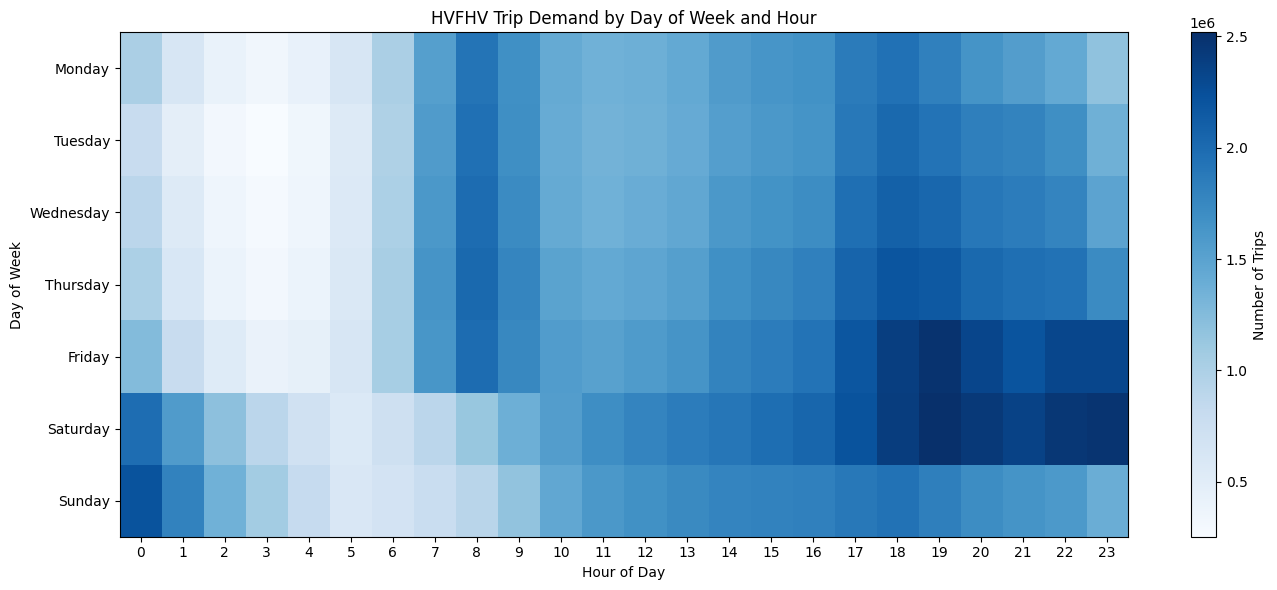

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.imshow(heatmap_data, aspect="auto", cmap="Blues")
plt.colorbar(label="Number of Trips")

plt.yticks(range(len(day_order)), day_order)
plt.xticks(range(24), range(24))

plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.title("HVFHV Trip Demand by Day of Week and Hour")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/MIT 805 Project/demand_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
zones_plot_df = top_zones_named.limit(10).toPandas()
zones_plot_df

,PULocationID,Zone,Borough,trip_count
0,138,LaGuardia Airport,Queens,742305
1,161,Midtown Center,Manhattan,676856
2,61,Crown Heights North,Brooklyn,621349
3,132,JFK Airport,Queens,609358
4,246,West Chelsea/Hudson Yards,Manhattan,589800
5,234,Union Sq,Manhattan,579367
6,231,TriBeCa/Civic Center,Manhattan,562391
7,79,East Village,Manhattan,555983
8,68,East Chelsea,Manhattan,515611
9,170,Murray Hill,Manhattan,484824


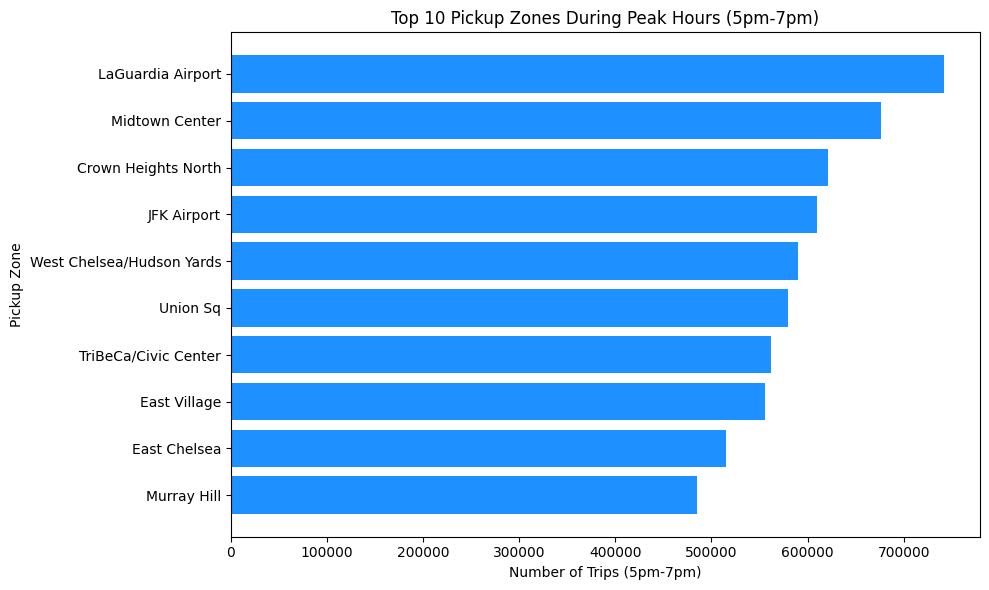

In [20]:
import matplotlib.pyplot as plt

zones_plot_df = zones_plot_df.sort_values("trip_count")

plt.figure(figsize=(10, 6))
plt.barh(zones_plot_df["Zone"], zones_plot_df["trip_count"], color="dodgerblue")

plt.xlabel("Number of Trips (5pm-7pm)")
plt.ylabel("Pickup Zone")
plt.title("Top 10 Pickup Zones During Peak Hours (5pm-7pm)")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/MIT 805 Project/top_zones_peak_hours.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
from pyspark.sql.functions import date_format

df = df.withColumn("pickup_year_month", date_format("pickup_datetime", "yyyy-MM"))

trips_by_month = (
    df.groupBy("pickup_year_month")
    .agg(count("*").alias("trip_count"))
    .orderBy("pickup_year_month"))

trips_by_month.show(20)

+-----------------+----------+
|pickup_year_month|trip_count|
+-----------------+----------+
|          2019-02|  20075504|
|          2019-07|  20222546|
|          2019-12|  21805569|
|          2020-05|   6079705|
|          2020-10|  13256489|
|          2021-04|  14091412|
|          2021-09|  14863192|
|          2022-02|  15998375|
|          2022-10|  19278299|
|          2023-03|  20396515|
|          2023-09|  19846166|
|          2024-02|  19347554|
|          2024-07|  19180018|
|          2024-12|  21063624|
+-----------------+----------+



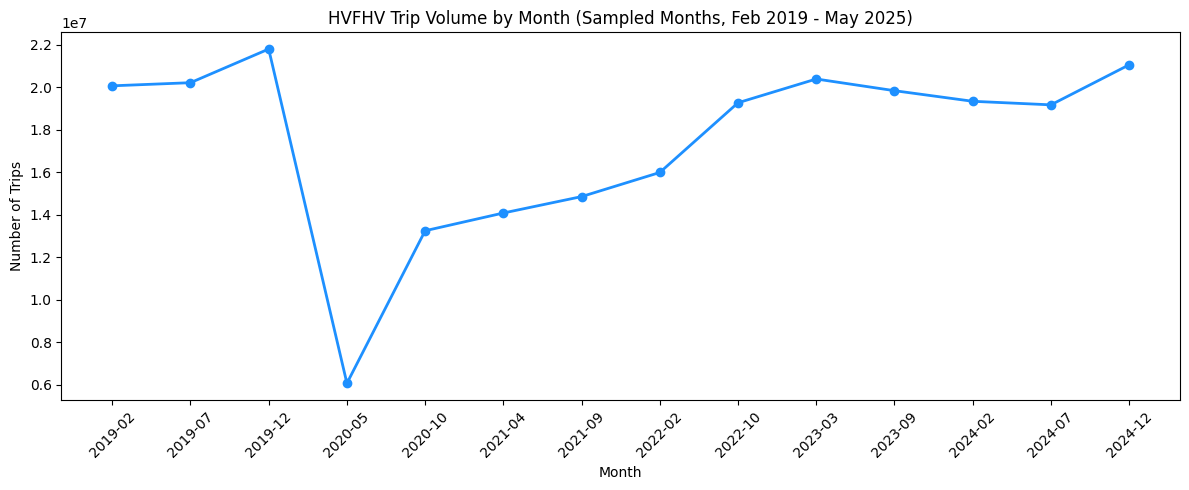

In [22]:
monthly_plot_df = trips_by_month.toPandas()

plt.figure(figsize=(12, 5))
plt.plot(monthly_plot_df["pickup_year_month"],
    monthly_plot_df["trip_count"],
    marker="o",
    color="dodgerblue",
    linewidth=2)

plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.title("HVFHV Trip Volume by Month (Sampled Months, Feb 2019 - May 2025)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/MIT 805 Project/trips_by_month.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
peak_hours = [17, 18, 19]
total_peak_trips = df.filter(df["pickup_hour"].isin(peak_hours)).count()
print("Total trips during peak hours (all zones): " + str(total_peak_trips))

Total trips during peak hours (all zones): 43783590
